In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df_balanceado = pd.read_csv('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_balanceado_completo.csv')

In [ ]:
df = df_balanceado[['text_cleaned', 'category_single']].dropna()

In [ ]:
print(df['category_single'].value_counts())

category_single
not_ciberbullying    40000
género               12399
edad                 10038
etnia                 6882
odio                  6253
otros                 2246
Name: count, dtype: int64


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['text_cleaned'])
y = df['category_single']

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [12]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'class_weight': ['balanced']
}

clf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(clf, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'], 'max_depth': [10, None],
                         'min_samples_leaf': [1], 'min_samples_split': [2],
                         'n_estimators': [100]},
             scoring='f1_macro', verbose=2)

                   precision    recall  f1-score   support

             edad       0.99      0.89      0.94      2008
            etnia       0.97      0.81      0.88      1376
           género       0.95      0.75      0.84      2480
not_ciberbullying       0.86      0.99      0.92      8000
             odio       0.94      0.83      0.88      1251
            otros       0.96      0.86      0.91       449

         accuracy                           0.91     15564
        macro avg       0.95      0.86      0.90     15564
     weighted avg       0.91      0.91      0.90     15564



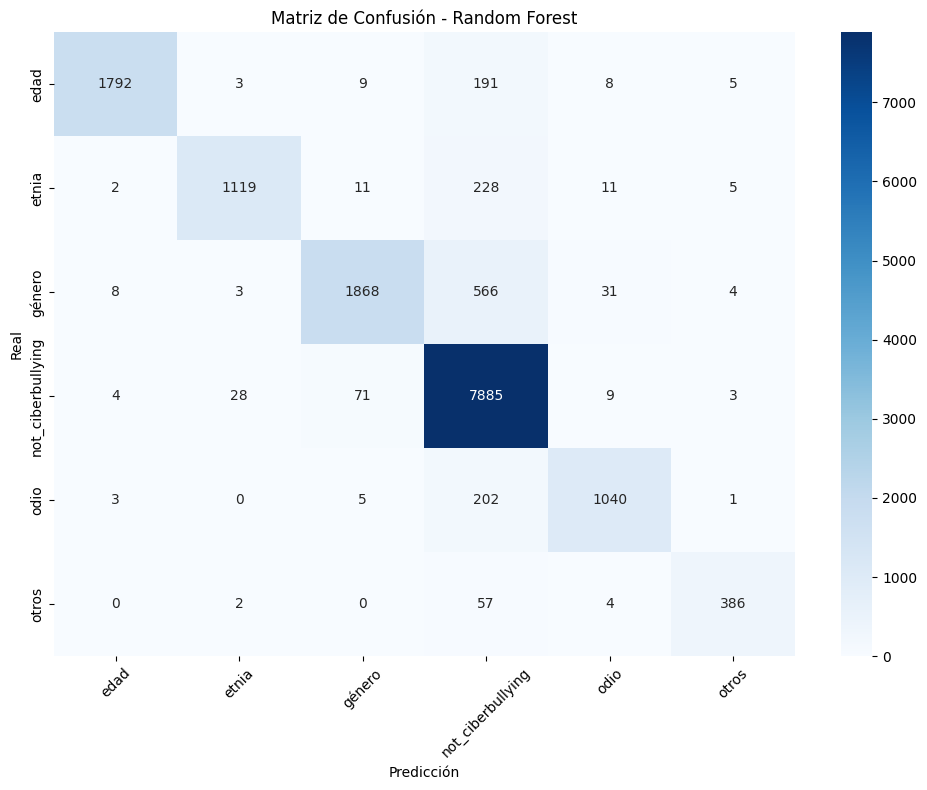

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

# Matriz de confusión
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()